In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [3]:
df=pd.read_csv("preprocessed_data.csv")
df.head()
df1=pd.read_csv("preprocessed_data.csv")

In [4]:
x=df1.drop(columns='Target')
y=df1['Target']
x_train, x_test, y_train, y_test=train_test_split(
    x,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [5]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

to_scale=['Age', 'Resting_BP', 'Serum_cholestrol', 'Max_Heartrate', 'OldPeak']

df1[to_scale]=scaler.fit_transform(df1[to_scale])

In [6]:
df1.head()

,Age,Gender,Chestpain,Resting_BP,Serum_cholestrol,Fasting_Blood_Sugar,Resting_Electrocardiogram,Max_Heartrate,Exercise_Induced_Angina,OldPeak,Slope,Number_of_Major_Vessels,Target
0,0.210464,1,2,0.642833,-0.024777,0,1,0.044567,0,1.507245,3,3,1
1,-0.517591,1,0,-1.928098,-0.906757,0,1,-0.891840,0,0.576955,1,1,0
2,-0.013553,1,2,-0.625938,-1.697812,0,0,1.654017,1,1.332816,1,0,0
3,-0.349578,1,0,-0.458995,-0.306647,1,1,0.220143,0,0.286239,2,2,1
4,-1.021629,1,1,1.577717,-0.024777,0,2,-0.277323,0,1.507245,3,2,1


In [7]:
smote=SMOTE(random_state=42)

x_train_smote, y_train_smote=smote.fit_resample(x_train,y_train)

print(f"Before Smote:", y_train.value_counts)
print(f"After Smote:" ,y_train_smote)

Before Smote: <bound method IndexOpsMixin.value_counts of 289    1
821    0
66     1
190    1
256    1
      ..
594    1
435    0
479    1
948    0
754    0
Name: Target, Length: 800, dtype: int64>
After Smote: 0      1
1      0
2      1
3      1
4      1
      ..
923    0
924    0
925    0
926    0
927    0
Name: Target, Length: 928, dtype: int64


In [8]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train_smote,y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
y_pred=model.predict(x_test)
y_prob = model.predict_proba(x_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98        84
           1       0.97      0.99      0.98       116

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200

ROC-AUC: 0.9984605911330049
Confusion Matrix:
 [[ 81   3]
 [  1 115]]


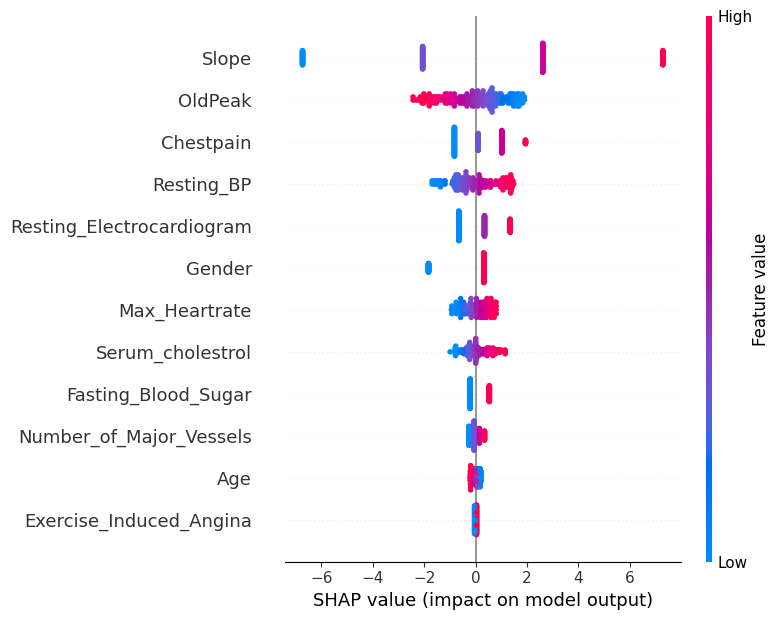

In [12]:
import shap

explainer = shap.LinearExplainer(model,x_train_smote)
shap_values = explainer.shap_values(x_test)

# Summary plot
shap.summary_plot(shap_values, x_test)